# PV & Wind Power Curve Models (Simple Version)

Erick Chauke

This is the plain-language companion to `notebook.ipynb`. That notebook compares six models
across three techniques (a physics formula, Gaussian Process regression, and tree-based
ensembles) for each of PV1, PV2, Wind1, Wind2, plus two pooled "combined" models, it is thorough,
but hard to walk someone through in a meeting.

This notebook keeps exactly one model per plant, the simplest one that is still a real,
explainable equation rather than a black box: a physics formula for the two PV plants, and a
classic wind-turbine power curve formula for the two wind plants. Both are computed directly
from a handful of numbers, they do not look anything up in the source data at prediction time.
The detailed notebook remains available as evidence that these simple formulas were the right
choice, not a claim taken on faith.

## Setup

Imports and the file path / plant capacities, the only things you would change to point this
notebook at a different input workbook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # enables the 3D plots below
import openpyxl
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit

In [2]:
# File path and each plant's installed nameplate capacity in megawatts, read from each sheet's
# title cell (row 0, col 0), e.g. "Installed Capacity: 75 MW".
DATA_PATH = "data/FPCs.xlsm"
CAPACITY_MW = {"PV1": 75.0, "PV2": 75.0, "Wind1": 102.0, "Wind2": 86.6}

# Number of folds for k-fold cross-validation: each formula is fit on 4/5 of its data and tested
# on the remaining 1/5, five times over, so every row gets used for testing exactly once. This
# gives a more honest accuracy estimate than testing on the same data the formula was fit on.
CV_FOLDS = 5

## Load the Data

Each sheet is a 2D grid, not row-per-observation data: row 1 holds the x-axis values, column 1
holds the y-axis values, and the title cell names the plant's capacity. Parsed by position here
because the merged header cells break pandas' automatic header detection.

In [3]:
def load_grid(sheet_name):
    """Read one FPCs.xlsm-style sheet into its x-axis, y-axis, and power grid."""
    df = pd.read_excel(DATA_PATH, sheet_name=sheet_name, header=None, engine="openpyxl")
    x_axis = df.iloc[1, 2:].astype(float).to_numpy()
    y_axis = df.iloc[2:, 1].astype(float).to_numpy()
    power_grid = df.iloc[2:, 2:].astype(float).to_numpy()
    return x_axis, y_axis, power_grid


def grid_to_tidy(x_axis, y_axis, power_grid, x_name, y_name):
    """Reshape a 2D grid into one row per (x, y) cell, dropping cells with no measurement."""
    y_mesh, x_mesh = np.meshgrid(y_axis, x_axis, indexing="ij")
    df = pd.DataFrame({y_name: y_mesh.ravel(), x_name: x_mesh.ravel(), "power": power_grid.ravel()})
    return df.dropna(subset=["power"]).reset_index(drop=True)

In [4]:
grids = {}
for sheet_name in ["PV1", "PV2", "Wind1", "Wind2"]:
    grids[sheet_name] = dict(zip(("x_axis", "y_axis", "power_grid"), load_grid(sheet_name)))

# Wind2 has one small negative-power artifact (measurement noise around zero wind speed, not
# real negative generation, confirmed in the detailed notebook's data-quality check). Clip it.
grids["Wind2"]["power_grid"] = np.clip(grids["Wind2"]["power_grid"], 0.0, None)

for name, g in grids.items():
    print(f"{name}: grid shape {g['power_grid'].shape}, {np.isnan(g['power_grid']).sum()} empty cells")

PV1: grid shape (28, 20), 262 empty cells
PV2: grid shape (28, 20), 292 empty cells
Wind1: grid shape (51, 24), 0 empty cells
Wind2: grid shape (51, 24), 0 empty cells


## PV1

$$P = \beta_0 \cdot G + \beta_1 \cdot G \cdot (T_m - 25)$$

$G$ is irradiance (W/m^2) and $T_m$ is module temperature (C). This is the standard
temperature-coefficient PV model [1], fit by ordinary least squares on this plant's own data.
It is a genuine equation: two numbers, multiplied and added, nothing more, computed the same way
whether $G$ and $T_m$ came from the training data or not.

In [5]:
pv1_df = grid_to_tidy(*load_grid("PV1"), x_name="module_temp", y_name="irradiance")
print(f"PV1: {len(pv1_df)} usable grid cells out of {grids['PV1']['power_grid'].size}")

PV1: 298 usable grid cells out of 560


In [6]:
X_pv1 = np.column_stack([
    pv1_df["irradiance"],
    pv1_df["irradiance"] * (pv1_df["module_temp"] - 25),
])
y_pv1 = pv1_df["power"].to_numpy()

# fit_intercept=False: zero irradiance should mean zero power, so the formula has no constant term.
pv1_model = LinearRegression(fit_intercept=False).fit(X_pv1, y_pv1)
beta0_pv1, beta1_pv1 = pv1_model.coef_
print(f"PV1 formula:  P = {beta0_pv1:.5f} * G + ({beta1_pv1:.6f}) * G * (Tm - 25)")

PV1 formula:  P = 0.06708 * G + (-0.000124) * G * (Tm - 25)


In [7]:
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=0)
r2_scores, rmse_scores = [], []
for train_idx, test_idx in kf.split(X_pv1):
    model = LinearRegression(fit_intercept=False).fit(X_pv1[train_idx], y_pv1[train_idx])
    pred = model.predict(X_pv1[test_idx])
    r2_scores.append(r2_score(y_pv1[test_idx], pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_pv1[test_idx], pred)))

print(f"PV1 accuracy: on unseen grid cells, this formula explains "
      f"{np.mean(r2_scores):.1%} of the variation in power output ($R^2$), "
      f"and is typically off by {np.mean(rmse_scores):.1f} MW (RMSE)")

PV1 accuracy: on unseen grid cells, this formula explains 93.8% of the variation in power output ($R^2$), and is typically off by 5.3 MW (RMSE)


### Graphs

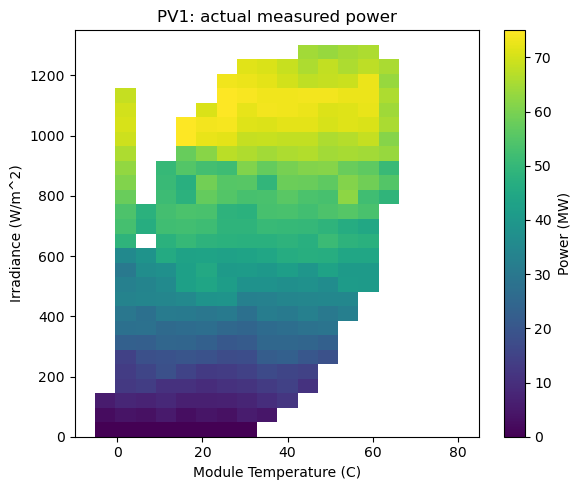

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    grids["PV1"]["power_grid"], origin="lower", aspect="auto",
    extent=[grids["PV1"]["x_axis"].min(), grids["PV1"]["x_axis"].max(),
            grids["PV1"]["y_axis"].min(), grids["PV1"]["y_axis"].max()],
    vmin=0, vmax=CAPACITY_MW["PV1"],
)
ax.set_xlabel("Module Temperature (C)")
ax.set_ylabel("Irradiance (W/m^2)")
ax.set_title("PV1: actual measured power")
fig.colorbar(im, ax=ax, label="Power (MW)")
fig.tight_layout()
fig.savefig("outputs_simple/pv1_actual_grid.png", dpi=150)
plt.show()

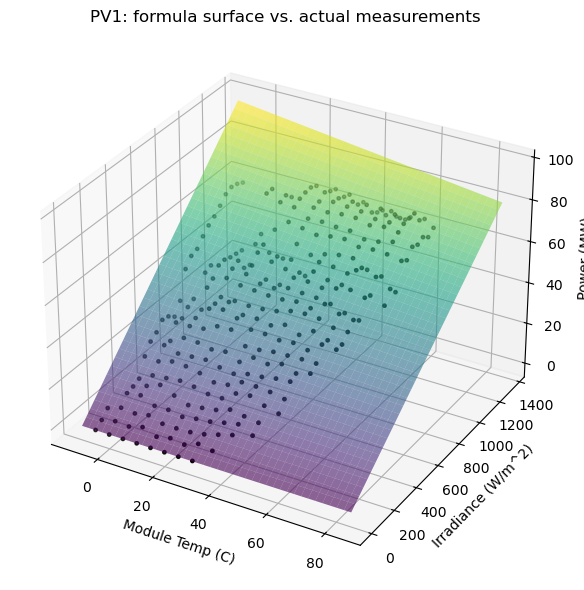

In [9]:
# 3D view: the dots are real measurements, the surface is the formula's prediction across the
# whole input range, including combinations never actually measured.
full_temp = np.linspace(grids["PV1"]["x_axis"].min(), grids["PV1"]["x_axis"].max(), 40)
full_irr = np.linspace(grids["PV1"]["y_axis"].min(), grids["PV1"]["y_axis"].max(), 40)
temp_grid, irr_grid = np.meshgrid(full_temp, full_irr)
pred_surface = pv1_model.predict(
    np.column_stack([irr_grid.ravel(), irr_grid.ravel() * (temp_grid.ravel() - 25)])
).reshape(irr_grid.shape)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(temp_grid, irr_grid, pred_surface, cmap="viridis", alpha=0.6, linewidth=0)
ax.scatter(pv1_df["module_temp"], pv1_df["irradiance"], pv1_df["power"],
           color="black", s=6, label="Actual measurements")
ax.set_xlabel("Module Temp (C)")
ax.set_ylabel("Irradiance (W/m^2)")
ax.set_zlabel("Power (MW)")
ax.set_title("PV1: formula surface vs. actual measurements")
fig.tight_layout()
fig.savefig("outputs_simple/pv1_3d_surface.png", dpi=150)
plt.show()

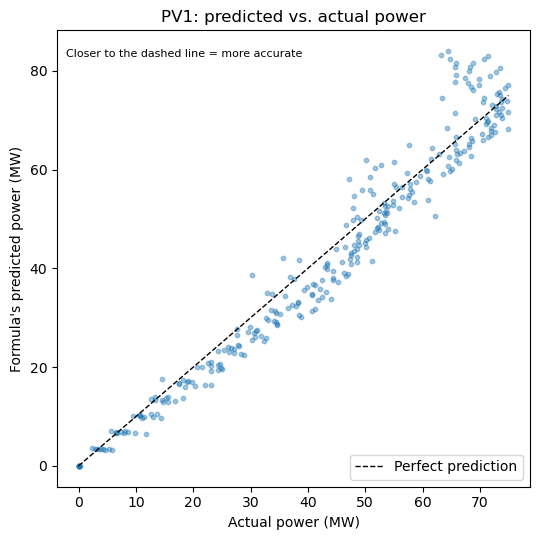

In [10]:
pred_pv1 = pv1_model.predict(X_pv1)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_pv1, pred_pv1, s=10, alpha=0.4)
lims = [0, CAPACITY_MW["PV1"]]
ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual power (MW)")
ax.set_ylabel("Formula's predicted power (MW)")
ax.set_title("PV1: predicted vs. actual power")
ax.text(0.02, 0.96, "Closer to the dashed line = more accurate", transform=ax.transAxes, fontsize=8, va="top")
ax.legend()
fig.tight_layout()
fig.savefig("outputs_simple/pv1_parity_plot.png", dpi=150)
plt.show()

### What this means

The PV1 formula is a straight line in irradiance, gently bent by module temperature. It
will never fit as tightly as a flexible statistical model can (see `notebook.ipynb` for that
comparison), but it is a real, quotable equation: give it any irradiance and temperature, in or
out of the measured range, and it computes an answer the same way every time.

## PV2

$$P = \beta_0 \cdot G + \beta_1 \cdot G \cdot (T_m - 25)$$

$G$ is irradiance (W/m^2) and $T_m$ is module temperature (C). This is the standard
temperature-coefficient PV model [1], fit by ordinary least squares on this plant's own data.
It is a genuine equation: two numbers, multiplied and added, nothing more, computed the same way
whether $G$ and $T_m$ came from the training data or not.

In [11]:
pv2_df = grid_to_tidy(*load_grid("PV2"), x_name="module_temp", y_name="irradiance")
print(f"PV2: {len(pv2_df)} usable grid cells out of {grids['PV2']['power_grid'].size}")

PV2: 268 usable grid cells out of 560


In [12]:
X_pv2 = np.column_stack([
    pv2_df["irradiance"],
    pv2_df["irradiance"] * (pv2_df["module_temp"] - 25),
])
y_pv2 = pv2_df["power"].to_numpy()

# fit_intercept=False: zero irradiance should mean zero power, so the formula has no constant term.
pv2_model = LinearRegression(fit_intercept=False).fit(X_pv2, y_pv2)
beta0_pv2, beta1_pv2 = pv2_model.coef_
print(f"PV2 formula:  P = {beta0_pv2:.5f} * G + ({beta1_pv2:.6f}) * G * (Tm - 25)")

PV2 formula:  P = 0.06077 * G + (-0.000160) * G * (Tm - 25)


In [13]:
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=0)
r2_scores, rmse_scores = [], []
for train_idx, test_idx in kf.split(X_pv2):
    model = LinearRegression(fit_intercept=False).fit(X_pv2[train_idx], y_pv2[train_idx])
    pred = model.predict(X_pv2[test_idx])
    r2_scores.append(r2_score(y_pv2[test_idx], pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_pv2[test_idx], pred)))

print(f"PV2 accuracy: on unseen grid cells, this formula explains "
      f"{np.mean(r2_scores):.1%} of the variation in power output ($R^2$), "
      f"and is typically off by {np.mean(rmse_scores):.1f} MW (RMSE)")

PV2 accuracy: on unseen grid cells, this formula explains 97.2% of the variation in power output ($R^2$), and is typically off by 3.4 MW (RMSE)


### Graphs

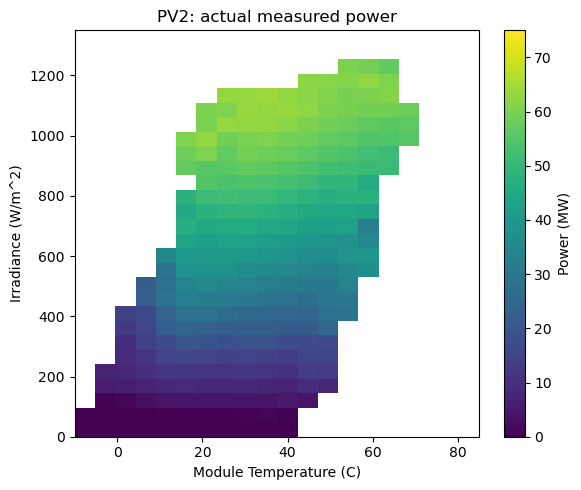

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    grids["PV2"]["power_grid"], origin="lower", aspect="auto",
    extent=[grids["PV2"]["x_axis"].min(), grids["PV2"]["x_axis"].max(),
            grids["PV2"]["y_axis"].min(), grids["PV2"]["y_axis"].max()],
    vmin=0, vmax=CAPACITY_MW["PV2"],
)
ax.set_xlabel("Module Temperature (C)")
ax.set_ylabel("Irradiance (W/m^2)")
ax.set_title("PV2: actual measured power")
fig.colorbar(im, ax=ax, label="Power (MW)")
fig.tight_layout()
fig.savefig("outputs_simple/pv2_actual_grid.png", dpi=150)
plt.show()

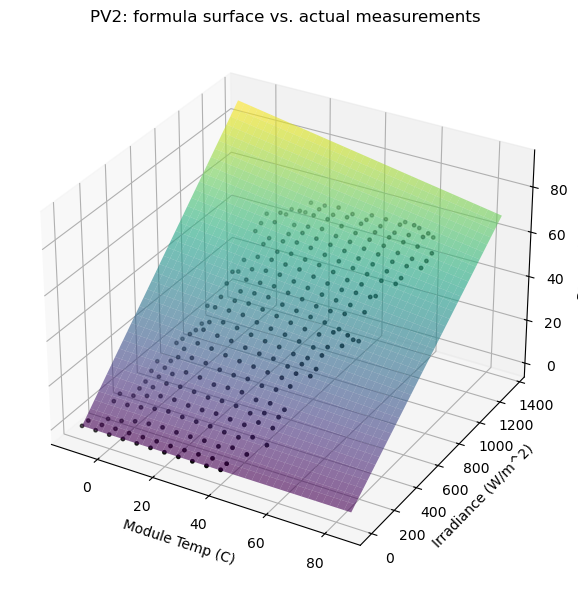

In [15]:
# 3D view: the dots are real measurements, the surface is the formula's prediction across the
# whole input range, including combinations never actually measured.
full_temp = np.linspace(grids["PV2"]["x_axis"].min(), grids["PV2"]["x_axis"].max(), 40)
full_irr = np.linspace(grids["PV2"]["y_axis"].min(), grids["PV2"]["y_axis"].max(), 40)
temp_grid, irr_grid = np.meshgrid(full_temp, full_irr)
pred_surface = pv2_model.predict(
    np.column_stack([irr_grid.ravel(), irr_grid.ravel() * (temp_grid.ravel() - 25)])
).reshape(irr_grid.shape)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(temp_grid, irr_grid, pred_surface, cmap="viridis", alpha=0.6, linewidth=0)
ax.scatter(pv2_df["module_temp"], pv2_df["irradiance"], pv2_df["power"],
           color="black", s=6, label="Actual measurements")
ax.set_xlabel("Module Temp (C)")
ax.set_ylabel("Irradiance (W/m^2)")
ax.set_zlabel("Power (MW)")
ax.set_title("PV2: formula surface vs. actual measurements")
fig.tight_layout()
fig.savefig("outputs_simple/pv2_3d_surface.png", dpi=150)
plt.show()

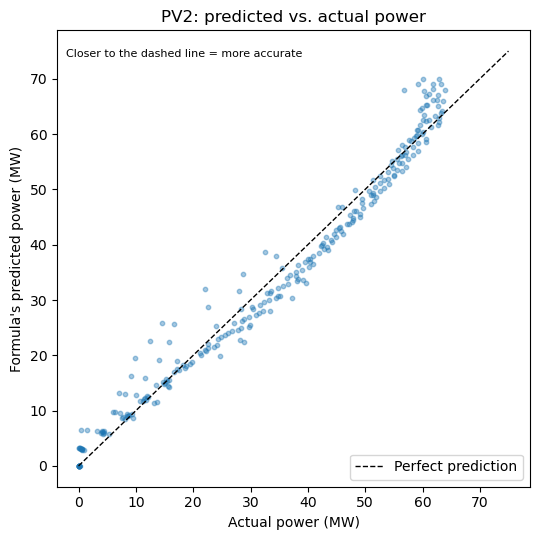

In [16]:
pred_pv2 = pv2_model.predict(X_pv2)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_pv2, pred_pv2, s=10, alpha=0.4)
lims = [0, CAPACITY_MW["PV2"]]
ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual power (MW)")
ax.set_ylabel("Formula's predicted power (MW)")
ax.set_title("PV2: predicted vs. actual power")
ax.text(0.02, 0.96, "Closer to the dashed line = more accurate", transform=ax.transAxes, fontsize=8, va="top")
ax.legend()
fig.tight_layout()
fig.savefig("outputs_simple/pv2_parity_plot.png", dpi=150)
plt.show()

### What this means

The PV2 formula is a straight line in irradiance, gently bent by module temperature. It
will never fit as tightly as a flexible statistical model can (see `notebook.ipynb` for that
comparison), but it is a real, quotable equation: give it any irradiance and temperature, in or
out of the measured range, and it computes an answer the same way every time.

## Wind Power Curve Formula

There is no physics formula for PV-style temperature-coefficient behavior in wind, so instead
this uses the standard cubic/approximate-cubic wind turbine power curve model from the wind
engineering literature [2], the same equation family used on manufacturer turbine spec sheets:

$$P(v) = \begin{cases} 0 & v < v_{ci} \ P_r \cdot \dfrac{v^k - v_{ci}^k}{v_r^k - v_{ci}^k} & v_{ci} \le v < v_r \ P_r & v \ge v_r \end{cases}$$

$v$ is wind velocity, $v_{ci}$ is the cut-in speed, $v_r$ is the rated speed, $P_r$ is the rated
power, and $k$ is a shape exponent (the idealized kinetic-energy case is $k=3$, since power in
moving air scales with velocity cubed, but real turbines deviate from that, so $k$ is fit to the
data). It only takes velocity as an input, not direction, since velocity dominates power output
far more than direction does (confirmed in `notebook.ipynb`'s SHAP analysis, direction matters
15-30x less than velocity).

In [17]:
def wind_power_curve(v, v_cutin, v_rated, p_rated, k):
    """Piecewise cubic-style wind turbine power curve: 0 below cut-in, p_rated above rated
    speed, and a v^k ramp in between."""
    v = np.asarray(v, dtype=float)
    power = np.zeros_like(v)
    ramp = (v >= v_cutin) & (v < v_rated)
    power[ramp] = p_rated * (v[ramp]**k - v_cutin**k) / (v_rated**k - v_cutin**k)
    power[v >= v_rated] = p_rated
    return power


def fit_wind_power_curve(velocity, power, capacity_mw):
    """Fit the four formula parameters to data via nonlinear least squares."""
    # Initial guess and search bounds: cut-in near 3 m/s, rated near 12 m/s, rated power near
    # nameplate capacity, shape exponent between linear (1) and the idealized cubic (up to 10).
    params, _ = curve_fit(
        wind_power_curve, velocity, power,
        p0=[3.0, 12.0, capacity_mw, 3.0],
        bounds=([0.0, 5.0, capacity_mw * 0.8, 1.0], [8.0, 20.0, capacity_mw * 1.2, 10.0]),
    )
    return params

## Wind1

In [18]:
wind1_df = grid_to_tidy(*load_grid("Wind1"), x_name="wind_direction", y_name="wind_velocity")
print(f"Wind1: {len(wind1_df)} usable grid cells out of {grids['Wind1']['power_grid'].size}")

Wind1: 1224 usable grid cells out of 1224


In [19]:
wind1_params = fit_wind_power_curve(wind1_df["wind_velocity"].to_numpy(), wind1_df["power"].to_numpy(), CAPACITY_MW["Wind1"])
wind1_cutin, wind1_rated, wind1_prated, wind1_k = wind1_params
print(f"Wind1 formula: cut-in = {wind1_cutin:.2f} m/s, rated speed = {wind1_rated:.2f} m/s, "
      f"rated power = {wind1_prated:.2f} MW, shape exponent k = {wind1_k:.2f}")

Wind1 formula: cut-in = 2.18 m/s, rated speed = 11.32 m/s, rated power = 101.56 MW, shape exponent k = 1.90


In [20]:
velocity_wind1 = wind1_df["wind_velocity"].to_numpy()
power_wind1 = wind1_df["power"].to_numpy()

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=0)
r2_scores, rmse_scores = [], []
for train_idx, test_idx in kf.split(velocity_wind1):
    fold_params = fit_wind_power_curve(velocity_wind1[train_idx], power_wind1[train_idx], CAPACITY_MW["Wind1"])
    pred = wind_power_curve(velocity_wind1[test_idx], *fold_params)
    r2_scores.append(r2_score(power_wind1[test_idx], pred))
    rmse_scores.append(np.sqrt(mean_squared_error(power_wind1[test_idx], pred)))

print(f"Wind1 accuracy: on unseen grid cells, this formula explains "
      f"{np.mean(r2_scores):.1%} of the variation in power output ($R^2$), "
      f"and is typically off by {np.mean(rmse_scores):.1f} MW (RMSE)")

Wind1 accuracy: on unseen grid cells, this formula explains 97.2% of the variation in power output ($R^2$), and is typically off by 6.9 MW (RMSE)


### Graphs

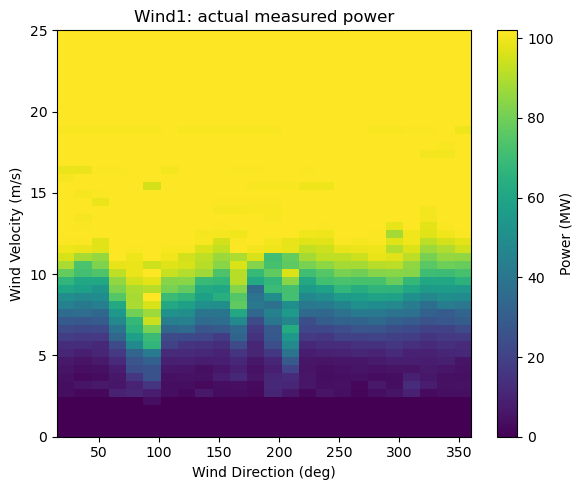

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    grids["Wind1"]["power_grid"], origin="lower", aspect="auto",
    extent=[grids["Wind1"]["x_axis"].min(), grids["Wind1"]["x_axis"].max(),
            grids["Wind1"]["y_axis"].min(), grids["Wind1"]["y_axis"].max()],
    vmin=0, vmax=CAPACITY_MW["Wind1"],
)
ax.set_xlabel("Wind Direction (deg)")
ax.set_ylabel("Wind Velocity (m/s)")
ax.set_title("Wind1: actual measured power")
fig.colorbar(im, ax=ax, label="Power (MW)")
fig.tight_layout()
fig.savefig("outputs_simple/wind1_actual_grid.png", dpi=150)
plt.show()

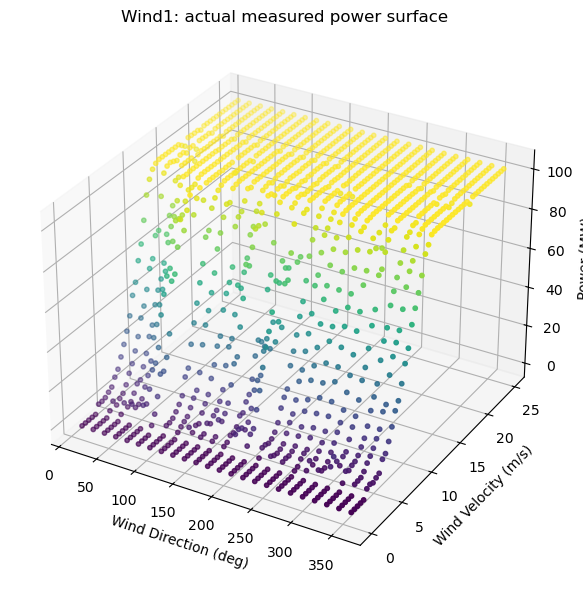

In [22]:
# 3D view of the real data: power rises with velocity (the dominant effect) and has a smaller,
# direction-dependent texture the formula below does not model, since it only uses velocity.
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(wind1_df["wind_direction"], wind1_df["wind_velocity"], wind1_df["power"],
           c=wind1_df["power"], cmap="viridis", s=10)
ax.set_xlabel("Wind Direction (deg)")
ax.set_ylabel("Wind Velocity (m/s)")
ax.set_zlabel("Power (MW)")
ax.set_title("Wind1: actual measured power surface")
fig.tight_layout()
fig.savefig("outputs_simple/wind1_3d_surface.png", dpi=150)
plt.show()

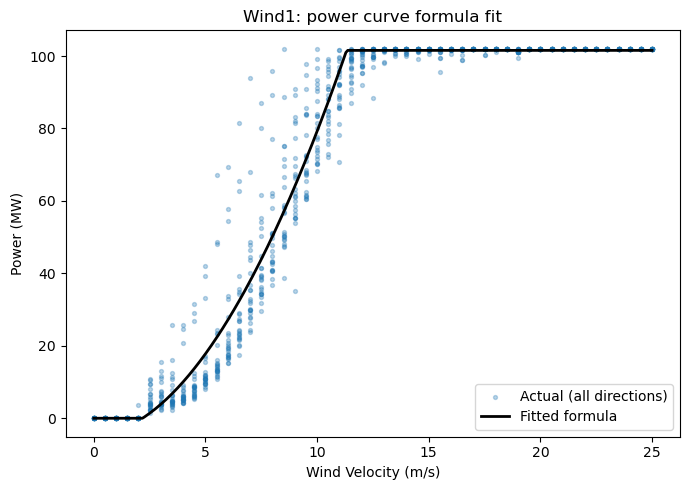

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(wind1_df["wind_velocity"], wind1_df["power"], s=8, alpha=0.3, label="Actual (all directions)")
v_line = np.linspace(0, grids["Wind1"]["y_axis"].max(), 300)
ax.plot(v_line, wind_power_curve(v_line, *wind1_params), color="black", linewidth=2, label="Fitted formula")
ax.set_xlabel("Wind Velocity (m/s)")
ax.set_ylabel("Power (MW)")
ax.set_title("Wind1: power curve formula fit")
ax.legend()
fig.tight_layout()
fig.savefig("outputs_simple/wind1_power_curve_fit.png", dpi=150)
plt.show()

### What this means

The Wind1 formula traces the classic wind turbine S-curve: no power below cut-in, a smooth
ramp, flat at rated capacity. It cannot see the small direction-dependent dip visible in the 3D
plot above, that costs some accuracy, but it is a real, quotable equation with four physically
meaningful numbers.

## Wind2

In [24]:
wind2_df = grid_to_tidy(*load_grid("Wind2"), x_name="wind_direction", y_name="wind_velocity")
print(f"Wind2: {len(wind2_df)} usable grid cells out of {grids['Wind2']['power_grid'].size}")

Wind2: 1224 usable grid cells out of 1224


In [25]:
wind2_params = fit_wind_power_curve(wind2_df["wind_velocity"].to_numpy(), wind2_df["power"].to_numpy(), CAPACITY_MW["Wind2"])
wind2_cutin, wind2_rated, wind2_prated, wind2_k = wind2_params
print(f"Wind2 formula: cut-in = {wind2_cutin:.2f} m/s, rated speed = {wind2_rated:.2f} m/s, "
      f"rated power = {wind2_prated:.2f} MW, shape exponent k = {wind2_k:.2f}")

Wind2 formula: cut-in = 3.23 m/s, rated speed = 11.44 m/s, rated power = 83.51 MW, shape exponent k = 1.16


In [26]:
velocity_wind2 = wind2_df["wind_velocity"].to_numpy()
power_wind2 = wind2_df["power"].to_numpy()

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=0)
r2_scores, rmse_scores = [], []
for train_idx, test_idx in kf.split(velocity_wind2):
    fold_params = fit_wind_power_curve(velocity_wind2[train_idx], power_wind2[train_idx], CAPACITY_MW["Wind2"])
    pred = wind_power_curve(velocity_wind2[test_idx], *fold_params)
    r2_scores.append(r2_score(power_wind2[test_idx], pred))
    rmse_scores.append(np.sqrt(mean_squared_error(power_wind2[test_idx], pred)))

print(f"Wind2 accuracy: on unseen grid cells, this formula explains "
      f"{np.mean(r2_scores):.1%} of the variation in power output ($R^2$), "
      f"and is typically off by {np.mean(rmse_scores):.1f} MW (RMSE)")

Wind2 accuracy: on unseen grid cells, this formula explains 98.5% of the variation in power output ($R^2$), and is typically off by 4.1 MW (RMSE)


### Graphs

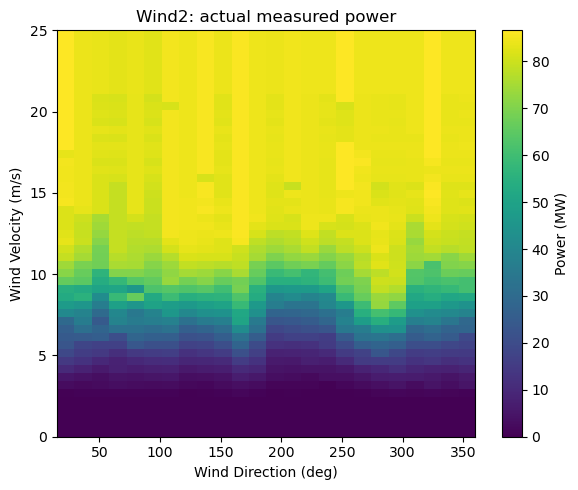

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    grids["Wind2"]["power_grid"], origin="lower", aspect="auto",
    extent=[grids["Wind2"]["x_axis"].min(), grids["Wind2"]["x_axis"].max(),
            grids["Wind2"]["y_axis"].min(), grids["Wind2"]["y_axis"].max()],
    vmin=0, vmax=CAPACITY_MW["Wind2"],
)
ax.set_xlabel("Wind Direction (deg)")
ax.set_ylabel("Wind Velocity (m/s)")
ax.set_title("Wind2: actual measured power")
fig.colorbar(im, ax=ax, label="Power (MW)")
fig.tight_layout()
fig.savefig("outputs_simple/wind2_actual_grid.png", dpi=150)
plt.show()

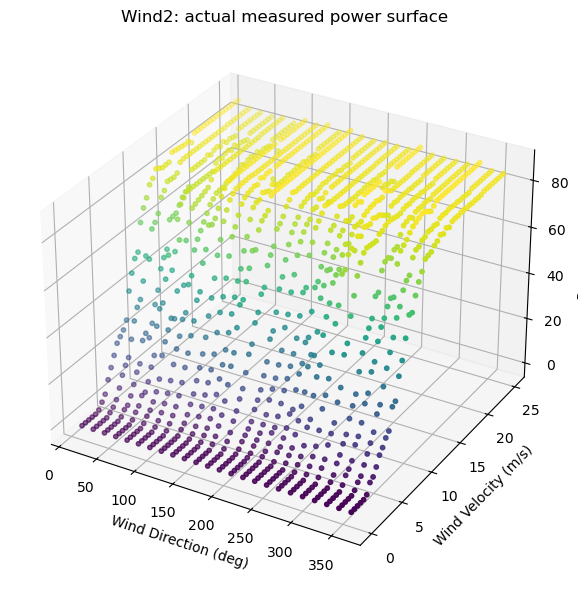

In [28]:
# 3D view of the real data: power rises with velocity (the dominant effect) and has a smaller,
# direction-dependent texture the formula below does not model, since it only uses velocity.
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(wind2_df["wind_direction"], wind2_df["wind_velocity"], wind2_df["power"],
           c=wind2_df["power"], cmap="viridis", s=10)
ax.set_xlabel("Wind Direction (deg)")
ax.set_ylabel("Wind Velocity (m/s)")
ax.set_zlabel("Power (MW)")
ax.set_title("Wind2: actual measured power surface")
fig.tight_layout()
fig.savefig("outputs_simple/wind2_3d_surface.png", dpi=150)
plt.show()

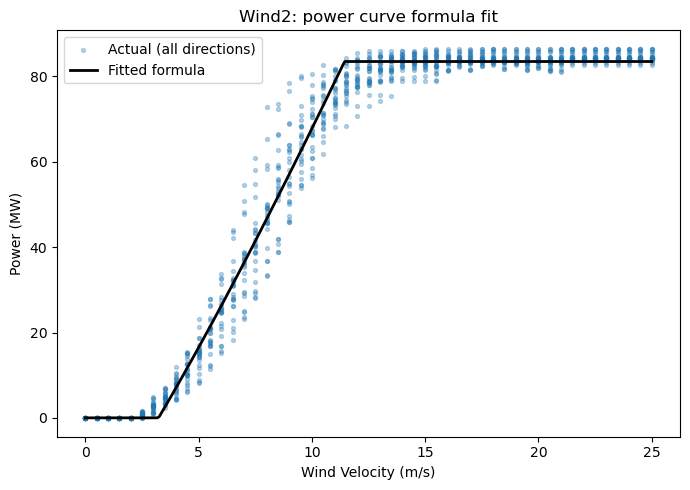

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(wind2_df["wind_velocity"], wind2_df["power"], s=8, alpha=0.3, label="Actual (all directions)")
v_line = np.linspace(0, grids["Wind2"]["y_axis"].max(), 300)
ax.plot(v_line, wind_power_curve(v_line, *wind2_params), color="black", linewidth=2, label="Fitted formula")
ax.set_xlabel("Wind Velocity (m/s)")
ax.set_ylabel("Power (MW)")
ax.set_title("Wind2: power curve formula fit")
ax.legend()
fig.tight_layout()
fig.savefig("outputs_simple/wind2_power_curve_fit.png", dpi=150)
plt.show()

### What this means

The Wind2 formula traces the classic wind turbine S-curve: no power below cut-in, a smooth
ramp, flat at rated capacity. It cannot see the small direction-dependent dip visible in the 3D
plot above, that costs some accuracy, but it is a real, quotable equation with four physically
meaningful numbers.

## Quick Reference

The four formulas, with their fitted numbers plugged in, all in one place.

In [30]:
print("PV1:  ", f"P = {beta0_pv1:.5f} * G + ({beta1_pv1:.6f}) * G * (Tm - 25)")
print("PV2:  ", f"P = {beta0_pv2:.5f} * G + ({beta1_pv2:.6f}) * G * (Tm - 25)")
print()
print("Wind1:", f"cut-in={wind1_cutin:.2f} m/s, rated={wind1_rated:.2f} m/s, "
                f"rated power={wind1_prated:.2f} MW, k={wind1_k:.2f}")
print("Wind2:", f"cut-in={wind2_cutin:.2f} m/s, rated={wind2_rated:.2f} m/s, "
                f"rated power={wind2_prated:.2f} MW, k={wind2_k:.2f}")
print()
print("G = irradiance (W/m^2), Tm = module temperature (C), v = wind velocity (m/s)")

PV1:   P = 0.06708 * G + (-0.000124) * G * (Tm - 25)
PV2:   P = 0.06077 * G + (-0.000160) * G * (Tm - 25)

Wind1: cut-in=2.18 m/s, rated=11.32 m/s, rated power=101.56 MW, k=1.90
Wind2: cut-in=3.23 m/s, rated=11.44 m/s, rated power=83.51 MW, k=1.16

G = irradiance (W/m^2), Tm = module temperature (C), v = wind velocity (m/s)


## References

[1] D.L. King, J.A. Kratochvil, W.E. Boyson, "Temperature Coefficients for PV Modules and Arrays:
Measurement Methods, Difficulties, and Results," Proc. 26th IEEE Photovoltaic Specialists
Conference, Anaheim, CA, Sept 29-Oct 3 1997, pp. 1183-1186, DOI: 10.1109/PVSC.1997.654300.

[2] C. Carrillo, A.F. Obando Montano, J. Cidras, E. Diaz-Dorado, "Review of power curve
modelling for wind turbines," Renewable and Sustainable Energy Reviews, vol. 21, pp. 572-581,
2013, DOI: 10.1016/j.rser.2013.01.012.